In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_features_selected.csv')

In [4]:
df.head()

,z1_AC2(kW),z1_AC3(kW),z1_Plug(kW),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),z2_S1(RH%),z2_S1(lux),z3_Light(kW),z3_Plug(kW),z4_AC1(kW),z4_Light(kW),z4_Plug(kW),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(RH%)
0,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.26,0.0,0.0,0.02,65.66,0.0,0.0,0.0,0.02,71.16
1,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.02,0.37,0.0,0.0,0.02,65.65,0.0,0.0,0.0,0.02,71.16
2,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.32,0.0,0.0,0.02,65.63,0.0,0.0,0.0,0.02,71.18
3,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.01,0.26,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.19
4,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.02,0.37,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.21


In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
features=list(df.columns)

In [6]:
features

['z1_AC2(kW)',
 'z1_AC3(kW)',
 'z1_Plug(kW)',
 'z1_S1(RH%)',
 'z1_S1(lux)',
 'z2_AC1(kW)',
 'z2_Light(kW)',
 'z2_Plug(kW)',
 'z2_S1(RH%)',
 'z2_S1(lux)',
 'z3_Light(kW)',
 'z3_Plug(kW)',
 'z4_AC1(kW)',
 'z4_Light(kW)',
 'z4_Plug(kW)',
 'z4_S1(RH%)',
 'z4_S1(lux)',
 'z5_AC1(kW)',
 'z5_Light(kW)',
 'z5_Plug(kW)',
 'z5_S1(RH%)']

In [7]:

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [8]:
kmeans_model=KMeans(n_clusters=2,random_state=42)

In [19]:
df['abnormal_kmeans'] = kmeans_model.fit_predict(df_scaled)



In [20]:
df

,z1_AC2(kW),z1_AC3(kW),z1_Plug(kW),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),z2_S1(RH%),z2_S1(lux),z3_Light(kW),z3_Plug(kW),z4_AC1(kW),z4_Light(kW),z4_Plug(kW),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(RH%),abnormal_kmeans
0,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.26,0.0,0.0,0.02,65.66,0.0,0.0,0.0,0.02,71.16,1
1,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.02,0.37,0.0,0.0,0.02,65.65,0.0,0.0,0.0,0.02,71.16,1
2,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.32,0.0,0.0,0.02,65.63,0.0,0.0,0.0,0.02,71.18,1
3,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.01,0.26,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.19,1
4,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.02,0.37,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.21,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264955,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00,1
264956,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.02,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00,1
264957,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00,1
264958,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00,1


In [21]:
df['abnormal_kmeans'].value_counts()

,count
abnormal_kmeans,
1,201844
0,63116


In [22]:
df['abnormal_kmeans'] = df['abnormal_kmeans'].apply(lambda x: 1 if x == 0 else 0)


In [23]:
df['abnormal_kmeans'].value_counts()

,count
abnormal_kmeans,
0,201844
1,63116


In [24]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df_scaled)

In [ ]:
df_pca[:,0]

array([-1.32668789, -1.20636499, -1.264352  , ..., -2.09935253,
       -2.09935253, -2.09338147])

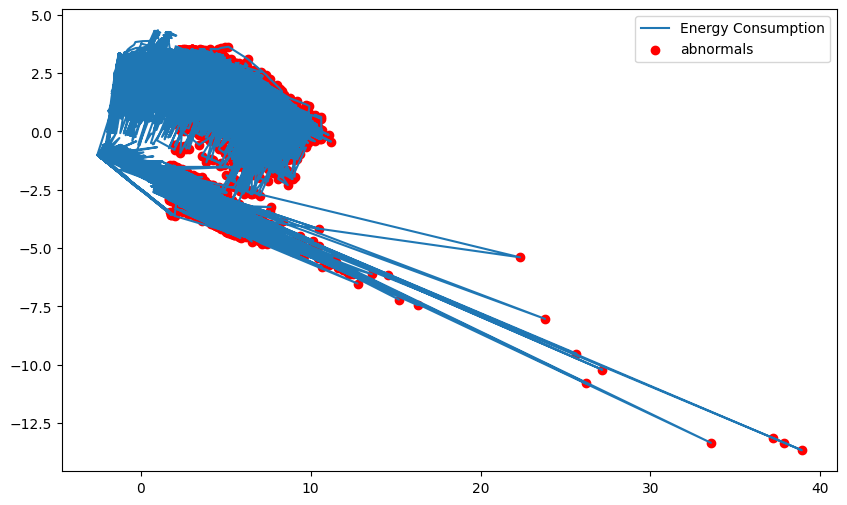

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(df_pca[:,0], df_pca[:,1], label='Energy Consumption')
plt.scatter(df_pca[:,0][df['abnormal_kmeans'] == 1],df_pca[:,1][df['abnormal_kmeans'] == 1], color='red', label='abnormals')
plt.legend()
plt.show()

In [27]:
df['abnormal']=df['abnormal_kmeans']

In [28]:
df.drop(['abnormal_kmeans'],axis=1).to_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_abnormals_kmeans.csv',index=False)

In [30]:
from sklearn.pipeline import Pipeline

In [35]:
df=df[features]

In [36]:
df

,z1_AC2(kW),z1_AC3(kW),z1_Plug(kW),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),z2_S1(RH%),z2_S1(lux),z3_Light(kW),z3_Plug(kW),z4_AC1(kW),z4_Light(kW),z4_Plug(kW),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(RH%)
0,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.26,0.0,0.0,0.02,65.66,0.0,0.0,0.0,0.02,71.16
1,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.02,0.37,0.0,0.0,0.02,65.65,0.0,0.0,0.0,0.02,71.16
2,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,0.01,0.32,0.0,0.0,0.02,65.63,0.0,0.0,0.0,0.02,71.18
3,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.01,0.26,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.19
4,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,0.02,0.37,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264955,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264956,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.02,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264957,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264958,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,0.01,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00


In [37]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KMeans(n_clusters=2,random_state=42))
])

In [38]:
df['abnormal_pipeline'] = pipeline.fit_predict(df)

df['abnormal_pipeline'] = df['abnormal_pipeline'].apply(lambda x: 1 if x == 0 else 0)


In [39]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df_scaled)

In [40]:
df_pca[:,0]

array([-1.32668789, -1.20636499, -1.264352  , ..., -2.09935253,
       -2.09935253, -2.09338147])

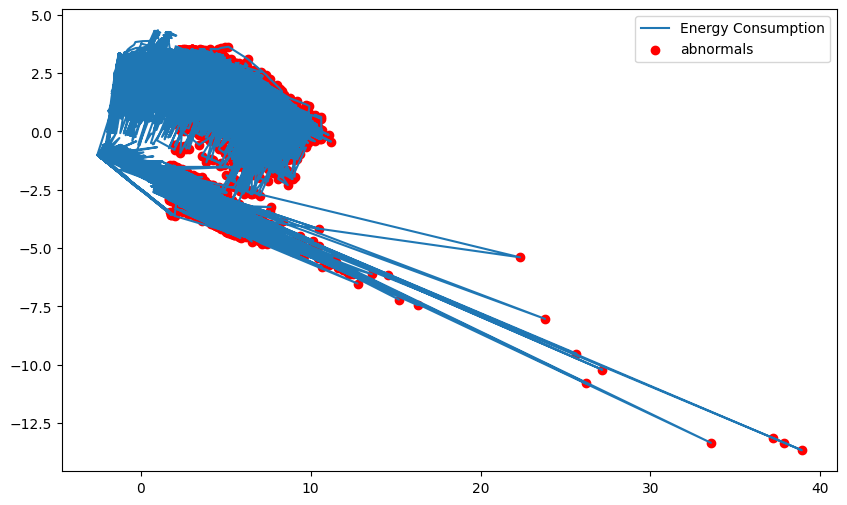

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(df_pca[:,0], df_pca[:,1], label='Energy Consumption')
plt.scatter(df_pca[:,0][df['abnormal_pipeline'] == 1],df_pca[:,1][df['abnormal_pipeline'] == 1], color='red', label='abnormals')
plt.legend()
plt.show()

In [42]:
import pickle

with open('drive/MyDrive/Intent-Based Energy Reduction/Abnormal Detection Model/model_kmeans.pkl', 'wb') as f:
  pickle.dump(kmeans_model, f)

with open('drive/MyDrive/Intent-Based Energy Reduction/Abnormal Detection Model/kmeans_pipeline.pkl', 'wb') as f:
  pickle.dump(pipeline, f)